In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

c:\FAHEEM\My_Programs\RAG_Beginners\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Google api key is set


In [2]:
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph.message import add_messages, BaseMessage
from langchain_core.documents import Document
from langchain_core.messages import ToolMessage
from pydantic import BaseModel, Field

class ItemSelection(BaseModel):
    item_id: int = Field(
        description="The item_id of the selected item. Must be the database item ID."
    )
    item_name: str = Field(
        description="The exact product name of the selected item."
    )

class support_schema(BaseModel):
    question: str
    ticket_id: str = Field(description="id used to fetch ticket support issues to user")
    
    type: Literal["Cancellation", "Refund", "Return", "Warranty", "Shipping"]
    customerID: str | None = Field(
        default=None,
        description="Customer ID"
    )
    orderID: str | None = Field(
        default=None,
        description="Order ID"
    )
    exists: Literal["Yes", "No"]
    status: Literal['open', 'in_progress', 'resolved', 'closed']
    priority: int = Field(description="0 means normal no priority given more then 0 means user needs support urgent")
    description: str = Field(description="Info about the issue user is facing and the ticket generated")
    item_list: list[ItemSelection] 

class llm_schema(BaseModel):
    type: Literal["Cancellation", "Refund", "Return", "Warranty", "Shipping"]
    question: str = Field(description="Reframed sentence into which type of poilcy(Cancellation, Refund, Return, Warranty, shipping) should be check for eligibility")
    product_info: str = Field(description="Product name, product buying date(in dd/mm/yyy format), product/order id etc")
    eligibility: Literal["Eligible", "Not Eligible"]
    answer: str

class graph_schema(TypedDict):
    query: str
    document: List[Document]
    product_info: str
    policy_question: str
    eligibility: Literal["Eligible", "Not Eligible"]
    item_list: list
    tool_calls: list
    tool_result: list[ToolMessage]
    conversation: Annotated[List[BaseMessage], add_messages]
    answer: str


In [3]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_support_schema = llm.with_structured_output(support_schema)

In [4]:
from langchain_core.tools import tool

@tool
def retriever_embedding_tool():
    """
    Retrieve relevant information from a specific local document.
    
    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.
    
    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
        web_link : Link that will be used to fecth information
    """

In [5]:
def get_order_item(id) -> graph_schema:
    orderData = order.fetch_order_by_id(id)
    
    if len(orderData) == 0:
        return {
            "answer": "I couldn't find an order with that order ID.",
        }
            
    items = order_item.fetch_order_items_by_id(id)
    if len(items) == 1:
        return {
            "item_list": items
        }

    item_list = [
        {
            "item_id": i[0],
            "item_name": i[2],
            "item_category": i[3],
            "item_price": i[5]
        }
        for i in items
    ]
    
    return {
        "answer": "Multiple items found in your order specify which one or all?",
        "item_list": item_list
    }

In [6]:
from Support_Tools.tools import create_ticket, update_ticket, cancel_order, process_refund, get_ticket

tools = [create_ticket, update_ticket, cancel_order, process_refund, get_ticket]

llm_with_tools = llm.bind_tools(tools)

In [7]:
from langchain_core.prompts import ChatPromptTemplate
import os
from langchain_core.messages import ToolMessage
from RagIntegration import RagRetriever
from datetime import datetime
from DB_Manager.customerDB import CustomerDatabaseManager
from DB_Manager.orderDB import OrderDatabaseManager
from DB_Manager.orderItemsDB import OrderItemDatabaseManager

retriever = RagRetriever()
customer = CustomerDatabaseManager()
order = OrderDatabaseManager()
order_item = OrderItemDatabaseManager()

def track_db_node(state: graph_schema) -> graph_schema:
    user_query = state["conversation"]
    result = llm_with_support_schema.invoke(user_query)
    print(result)


    if result.item_list and result.item_list[0].item_id:
        print(f"Your selected Item{result.item_list}")

        selected_product = result.item_list[0]
        
        product_info = order_item.fetch_item_by_id(selected_product.item_id)
        
        product_info = {
            "delivery_date": product_info[9],
            "delivery_status": product_info[10],
            "product_id": product_info[0],
            "product_name": product_info[2],
            "product_category": product_info[3],
            "product_price": product_info[5]
        }
        
        delivery_date = datetime.fromisoformat(product_info['delivery_date'])
        current_date = datetime.now()
        
        print(f"Today's date: {current_date} and delivery date: {delivery_date}")
        
        if delivery_date > current_date and result.type == "Return":
            return {
                "answer": "Order is not delivered yet if you want you can cancel it instead of return"
                }
        
        print(f"Your product info: {product_info}")
        return {
            "product_info": product_info,
            "query": result.question
        }

    elif result.orderID:
        return get_order_item(result.orderID)
        
    
    elif result.customerID:
        orderData = order.fetch_order_by_customer_id(result.customerID)
        if len(orderData) == 0:
            return {
                "answer": "You don't have any orders",
            }
        
        elif len(orderData) > 1:
            return {
                "answer": "You have multiple orders provide order id"
            }
        else:
            return get_order_item(orderData[0].orderID)

    
    else:
        return {
            "answer": "Please provide your order ID or customer ID."
        }
    
def decision_node(state: graph_schema) -> str:
    answer = state['answer']

    if answer:
        return "end"
    else:
        return "retriever_node"


def retriever_node(state:graph_schema) -> graph_schema:

    query = state["query"]
    result = llm_with_schema.invoke(query)
    print(result)
    policy_dir = "Policies"

    policy_files = {
        "Return": "RETURN_POLICY.pdf",
        "Cancellation": "CANCELLATION_POLICY.pdf",
        "Refund": "REFUND_POLICY.pdf",
        "Warranty": "WARRANTY_POLICY.pdf",
        "Shipping": "SHIPPING_POLICY.pdf",
        "Payment": "PAYMENT_FAQ.pdf"
    }

    file_path = os.path.join(
        policy_dir,
        policy_files[result.type]
    )

    print("Loading:", file_path)
    print("Exists:", os.path.exists(file_path))

    retriever.file_loader(file_path)
    retriever.text_splitting()
    response = retriever.vector_embedding(result.question)

    return {
        "policy_question": result.question,
        "document": response
    }

def generator_node(state: graph_schema) -> graph_schema:
    user_query = state["query"]
    document = state["document"]
    question = state["policy_question"]
    product_info = state["product_info"]

    context = "\n\n".join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
    ("system", """
        You are a customer support assistant for an e-commerce company.

        Your task is to answer the user's original question using:
        1. The retrieved company policy as the authoritative source for policy rules.
        2. The customer's product/order information when determining eligibility.
        3. The original user question to understand what the customer wants.

        Instructions:
        - Use the retrieved policy as the source of truth for company rules.
        - Use the product/order information only for facts about the customer's specific product or order.
        - Compare the customer's product/order information against the requirements in the policy when determining eligibility.
        - Do not invent policy rules, customer information, order information, dates, prices, or eligibility conditions.
        - If the policy does not provide enough information to determine eligibility, clearly state that you cannot determine eligibility from the available information.
        - If the customer's product/order information is missing, ask the customer for the required information.
        - If the customer is eligible, clearly explain why based on the policy.
        - If the customer is not eligible, clearly explain which policy requirement is not satisfied.
        - The date provided to you is either delivery date
        - Answer the original user's question, not merely the reframed policy question.
        - Also return eligibility if eligible or not
        - Keep the response clear and direct.
        - Do not mention the RAG system, retrieval process, embeddings, vector database, or internal tools.
        
        Retrieved Policy Context:
        {context}

        Customer/Product Information:
        {product_info}

        Policy_question:
        {question}
    """),

    ("user", """
        Original Customer Question:
        {user_query}
    """)
])

    chain = prompt | llm_with_schema

    result = chain.invoke({"context": context, "product_info": product_info, "question": question, "user_query": user_query})
    print(result.answer)
    return {
        "answer": result.answer,
        "eligibility": result.eligibility
    }

def support_needed(state: graph_schema) -> str:
    if state['eligibility'] == "Eligible":
        return "support_node"
    else:
        return "end"

def support_node(state: graph_schema) -> graph_schema:
    query = state["conversation"]
    result = llm_with_tools.invoke(query)

    return {
        "tool_calls": result.tool_calls
    }

def tool_node(state: graph_schema) -> graph_schema:
    tool_calls = state['tool_calls']

    tool_name = {tool.name: tool for tool in tools}

    tool_result = []
    for tool_call in tool_calls:
        tool = tool_name[tool_call["name"]]
        observation = decide_tool(graph_schema, tool, tool_call["name"], tool_call["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))

    return {
        "tool_result": tool_result
    }

def decide_tool(state: graph_schema, tool, tool_name, tool_args):
    if tool_name == "create_ticket":
        print("Create Ticket tool raised")

    elif tool_name == "update_ticket":
        print("Update Ticket tool raised")

    elif tool_name == "cancel_order":
        item_id = tool_args['item_id']
        response = order_item.fetch_item_by_id(item_id)
        order_id = response[1]
        response = tool.invoke({"order_id":order_id, "item_id":item_id})
        print(f"Response after cancel order: {response}")

    elif tool_name == "process_refund":
        print("Create Ticket tool raised")

    else:
        pass

def response_node(state: graph_schema) -> graph_schema:

    tool_result = "\n".join(
        message.content for message in state["tool_result"]
    )

    prompt = f"""
    Original request:
    {state["conversation"]}

    Previous analysis:
    {state["answer"]}

    Tool execution result:
    {tool_result}

    Give the customer a clear final response.
    """

    result = llm.invoke(prompt)

    return {
        "answer": result.content
    }


USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4973.96it/s]


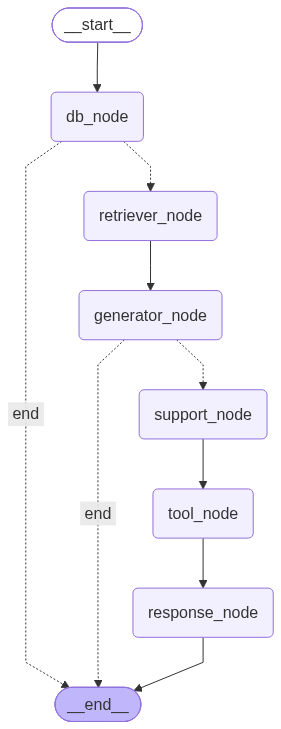

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("db_node", track_db_node)
graph.add_node("generator_node", generator_node)
graph.add_node("support_node", support_node)
graph.add_node("tool_node", tool_node)
graph.add_node("response_node", response_node)

graph.add_edge(START, "db_node")
graph.add_conditional_edges("db_node", decision_node, {"retriever_node": "retriever_node", "end": END})
graph.add_edge("retriever_node", "generator_node")
graph.add_conditional_edges("generator_node", support_needed, {"support_node": "support_node", "end": END})
graph.add_edge("support_node", "tool_node")
graph.add_edge("tool_node", "response_node")
graph.add_edge("response_node", END)

customer_support_agent = graph.compile()

customer_support_agent

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from memory import LocalMemory
#ORDTHCG
#ORDFFZ7
memory = LocalMemory()

conversation = []
while True:
    user_query = input("Enter your query (stop to end)...")
    if user_query.lower() == "stop":
        print("Execution Stopped...")
        break

    conversation.append(HumanMessage(content=user_query))

    response = customer_support_agent.invoke({
    "query": user_query,
    "document": [],
    "policy_question":"",
    "product_info": "",
    "eligible": "",
    "answer": "",
    "conversation": conversation,
    "item_list": []
})

    print(response['answer'][0]['text'])
    if response['item_list']:
        print(f"Items:")

        for index, item in enumerate(response["item_list"], start=1):
            print(f"Id: {item['item_id']}")
            print(f"item name: {item['item_name']}")
            print(f"   Category: {item['item_category']}")
            print(f"   Price: ₹{item['item_price']:,.2f}")
            print()

        print("Specify atleast id and name")

    conversation.append(AIMessage(content=response['answer'][0]['text']))
    memory.save_memory(conversation)


question='cancel my order of item id 7' ticket_id='TKT-1007' type='Cancellation' customerID=None orderID=None exists='No' status='open' priority=0 description='User requested cancellation for item id 7.' item_list=[ItemSelection(item_id=7, item_name='Unknown Item')]
Your selected Item[ItemSelection(item_id=7, item_name='Unknown Item')]
Today's date: 2026-08-20 20:11:47.805260 and delivery date: 2026-08-25 00:00:00
Your product info: {'delivery_date': '2026-08-25', 'delivery_status': 'Order Placed', 'product_id': 7, 'product_name': 'Shirt', 'product_category': 'Cloth', 'product_price': 500.0}
type='Cancellation' question='Am I eligible to cancel my order with item ID 7?' product_info='Item ID 7' eligibility='Eligible' answer='Yes, you are eligible to cancel your order as long as it has not yet been processed for shipment. Please visit your order history page to initiate the cancellation.'
Loading: Policies\CANCELLATION_POLICY.pdf
Exists: True
Yes, you are eligible to cancel your order f

In [10]:
from memory import LocalMemory

memory = LocalMemory()

result = memory.load_memory()

for conversation in result[-5:]:
    print(conversation["page_content"])
    print("-" * 50)


HUMAN: want to cancel an order of id ORDFFZ7
AI: Multiple items found in your order specify which one or all?
--------------------------------------------------
HUMAN: want to cancel an order of id ORDFFZ7
AI: Multiple items found in your order specify which one or all?
HUMAN: all
AI: Multiple items found in your order specify which one or all?
--------------------------------------------------
HUMAN: want to cancel an order of id ORDFFZ7
AI: Multiple items found in your order specify which one or all?
HUMAN: all
AI: Multiple items found in your order specify which one or all?
HUMAN: item of id 7
AI: Yes, you are eligible to cancel your order ORDFFZ7. According to our policy, customers can cancel an order before it has been shipped. Since your order status is currently 'Order Placed' and has not yet entered the shipping process, you may proceed with the cancellation. Please provide the reason for your cancellation request to complete the process.
---------------------------------------

In [11]:
from DB_Manager.customerDB import CustomerDatabaseManager
from DB_Manager.orderDB import OrderDatabaseManager
from DB_Manager.orderItemsDB import OrderItemDatabaseManager

customer = CustomerDatabaseManager()
order = OrderDatabaseManager()
order_item = OrderItemDatabaseManager()
#ORDFFZ7

result = order.fetch_order_by_id("ORDFFZ7")
result

[('ORDFFZ7',
  101,
  '2026-08-18',
  '2026-08-25',
  'Cancel',
  1164.0,
  'Cash on delivery',
  7,
  'Shirt',
  'Cloth',
  2,
  500.0,
  'Good'),
 ('ORDFFZ7',
  101,
  '2026-08-18',
  '2026-08-25',
  'Cancel',
  1164.0,
  'Cash on delivery',
  8,
  'Cargo Pant',
  'Cloth',
  1,
  565.0,
  'Good'),
 ('ORDFFZ7',
  101,
  '2026-08-18',
  '2026-08-25',
  'Cancel',
  1164.0,
  'Cash on delivery',
  9,
  'Key Chain',
  'Accessories',
  1,
  99.0,
  'Good')]